# Naive Bayes — Classification (Google Colab)

**Goal:** Predict a **binary class** (0/1) using **Naive Bayes** — applies **Bayes' theorem** with a **naive independence** assumption between features.

| Example | Feature(s) (X) | Target (y) | Dataset |
|---------|----------------|------------|---------|
| **Example 1** | Age, EstimatedSalary | Purchased (0/1) | `../Datasets/social_network_ads.csv` |
| **Example 2** | CreditScore, Income, LoanAmount, YearsEmployed | Approved (0/1) | `../Datasets/loan_approval.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| — | Algorithm Guide | Bayes theorem, Gaussian NB, independence |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

---
# Algorithm Guide — Naive Bayes (Gaussian)

## What is Naive Bayes?

**Naive Bayes** is a **probabilistic** classifier based on **Bayes' theorem**. It predicts the class with the **highest posterior probability**.

| Property | Detail |
|----------|--------|
| Type | **Generative** model — learns P(x \| class) and P(class) |
| "Naive" | Assumes features are **independent** given the class |
| Output | Class label + **class probabilities** |
| Speed | Very **fast** training and prediction |

## Bayes' Theorem

`P(class | x) = P(x | class) · P(class) / P(x)`

For classification we compare:

`P(class | x) ∝ P(class) · P(x | class)`

Predict the class with the **largest** posterior probability.

## The "Naive" Independence Assumption

Features are assumed **conditionally independent** given the class:

`P(x₁, x₂, … | class) = P(x₁ | class) · P(x₂ | class) · …`

| Reality | Naive Bayes assumption |
|---------|------------------------|
| Features often correlated | Treats each feature **separately** |
| Effect | Simplifies math — works surprisingly well in practice |

## Gaussian Naive Bayes (continuous features)

For each class **c** and feature **j**, sklearn estimates:

| Parameter | Meaning |
|-----------|---------|
| **Prior** P(c) | Fraction of training samples in class c |
| **Mean μ_cj** | Average of feature j in class c |
| **Variance σ²_cj** | Spread of feature j in class c |

Each feature is modeled as a **Gaussian (normal) bell curve** per class.

## Prediction Steps

| Step | Action |
|------|--------|
| 1 | Estimate **priors** P(class) from training labels |
| 2 | For each class, estimate **mean & variance** of every feature |
| 3 | For a new point **x**, compute likelihood under each class (product of Gaussians) |
| 4 | Multiply by prior → pick class with **highest posterior** |

## Naive Bayes vs Other Classifiers

| | Logistic Regression | K-NN | **Naive Bayes** |
|---|---------------------|------|-----------------|
| Scaling | Recommended | **Required** | **Not required** (Gaussian NB) |
| Training speed | Fast | Stores all data | **Very fast** |
| Assumption | Linear log-odds | None (local) | Independence + Gaussian |
| Small data | OK | OK | Often **works well** |

## Variants in sklearn

| Class | Use case |
|-------|----------|
| `GaussianNB` | Continuous numeric features |
| `MultinomialNB` | Count data (e.g. word counts in text) |
| `BernoulliNB` | Binary features (0/1) |

## What the Student Must Remember

1. Naive Bayes uses **Bayes' theorem** + **feature independence**.
2. **GaussianNB** fits a **bell curve** per feature per class.
3. **No feature scaling** needed for Gaussian Naive Bayes.
4. Outputs **probabilities** via `predict_proba()`.
5. Fast baseline — great for **spam detection**, **text**, and quick prototypes.

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [55]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for preprocessing, Gaussian Naive Bayes, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, sklearn GaussianNB, and metrics.

In [56]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots

from sklearn.model_selection import train_test_split       # Split data into train/test
from sklearn.impute import SimpleImputer                   # Fill missing values
from sklearn.naive_bayes import GaussianNB                 # Gaussian Naive Bayes classifier
from sklearn.metrics import (                              # Classification metrics
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Example 1: Social Network Ads — Naive Bayes

Predict whether a user **Purchased** from **Age** and **EstimatedSalary** using Gaussian Naive Bayes.

| Column | Role | Description |
|--------|------|-------------|
| `Age` | Feature (X₁) | User age in years |
| `EstimatedSalary` | Feature (X₂) | Estimated annual salary in USD |
| `Purchased` | Target (y) | 0 = No, 1 = Yes |

**File:** `../Datasets/social_network_ads.csv`

---
# Phase 1: Data Pre-processing

Prepare the data before training — same template is reused for other algorithms.

## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/social_network_ads.csv` and displays basic statistics.

In [57]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/social_network_ads.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['Age', 'EstimatedSalary']  # Two numeric input features
TARGET_COL = 'Purchased'                    # Binary target: 0 = No, 1 = Yes

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nClass balance ({TARGET_COL}):')
print(dataset[TARGET_COL].value_counts())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,Age,EstimatedSalary,Purchased
0,56,115235,1
1,46,89740,1
2,32,131352,1
3,60,81617,0
4,25,31896,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB

Statistical summary:


,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,39.605000,80844.840000,0.420000
std,12.374846,39484.169884,0.494177
min,18.000000,15404.000000,0.000000
25%,29.000000,42699.750000,0.000000
50%,41.000000,81218.500000,0.000000
75%,50.000000,117134.250000,1.000000
max,60.000000,149668.000000,1.000000



Class balance (Purchased):
Purchased
0    232
1    168
Name: count, dtype: int64

Shape: 400 rows x 3 columns


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values, remove duplicates, and apply imputation if needed.

**What this cell does:** Cleans the dataset before modeling.

In [58]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
rows_after = len(dataset)
print(f'\nDuplicates removed: {rows_before - rows_after}')

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
if dataset.isnull().sum().sum() > 0:
    dataset[num_cols] = imputer.fit_transform(dataset[num_cols])
    print('Missing values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {rows_after}')

Missing values per column:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 400


## Example 1 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [59]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')
    print(f'Target column: {TARGET_COL} (already 0/1)')

No categorical columns — encoding skipped.
Feature columns: ['Age', 'EstimatedSalary']
Target column: Purchased (already 0/1)


## Example 1 — Cell 4: Splitting the Data

Define X and y, then split 80/20 with **stratify** to preserve class ratio.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [60]:
# Step 4) Train-Test split (stratified for classification)

X = dataset[FEATURE_COLS].values  # Feature matrix: Age and EstimatedSalary
y = dataset[TARGET_COL].values    # Target vector: Purchased (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train class counts: {np.bincount(y_train)}')
print(f'y_test class counts:  {np.bincount(y_test)}')

X_train shape: (320, 2)
X_test shape:  (80, 2)
y_train class counts: [186 134]
y_test class counts:  [46 34]


> **Note:** **Gaussian Naive Bayes** does **not** require feature scaling — it models each feature's distribution separately per class.

---
# Phase 2: Naive Bayes — Social Network Ads

Train GaussianNB and evaluate on the test set.

## Example 1 — Cell 5: Train the Model

Fit `GaussianNB` — estimates class priors and per-feature Gaussian parameters.

**What this cell does:** Trains the classifier and displays learned priors and means.

In [61]:
# Step 5) Train Gaussian Naive Bayes

classifier = GaussianNB()  # Gaussian NB for continuous features
classifier.fit(X_train, y_train)  # Estimate priors, means, and variances per class

print('Gaussian Naive Bayes trained successfully.')
print(f'Class labels: {classifier.classes_}')  # [0, 1]
print(f'Class priors P(c): {classifier.class_prior_.round(4)}')  # Prior probability per class

print('\nFeature means per class (rows=class 0/1, cols=Age, Salary):')
for i, cls in enumerate(classifier.classes_):
    label = 'Not Purchased' if cls == 0 else 'Purchased'
    means = classifier.theta_[i]  # Mean of each feature for this class
    print(f'  Class {cls} ({label}): Age={means[0]:.1f}, Salary={means[1]:,.0f}')

Gaussian Naive Bayes trained successfully.
Class labels: [0 1]
Class priors P(c): [0.5812 0.4188]

Feature means per class (rows=class 0/1, cols=Age, Salary):
  Class 0 (Not Purchased): Age=35.7, Salary=67,074
  Class 1 (Purchased): Age=44.5, Salary=101,784


## Example 1 — Cell 6: Predict

Predict class labels and **posterior probabilities** on the test set.

**What this cell does:** Uses `predict()` and `predict_proba()` from Bayes' rule.

In [62]:
# Step 6) Predict classes and probabilities

y_pred_train = classifier.predict(X_train)            # Class labels for training set
y_pred_test = classifier.predict(X_test)              # Class labels for test set
y_proba_test = classifier.predict_proba(X_test)[:, 1]  # P(Purchased=1 | x) from Bayes

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    label = 'Yes' if y_pred_test[i] == 1 else 'No'
    actual = 'Yes' if y_test[i] == 1 else 'No'
    print(f'  Actual={actual}, Predicted={label}, P(Purchase|x)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=No, Predicted=No, P(Purchase|x)=17.28%
  Actual=Yes, Predicted=Yes, P(Purchase|x)=71.04%
  Actual=Yes, Predicted=No, P(Purchase|x)=26.38%
  Actual=No, Predicted=No, P(Purchase|x)=29.76%
  Actual=No, Predicted=No, P(Purchase|x)=34.74%


## Example 1 — Cell 7: Visualization

Plot data points and the **Naive Bayes decision boundary**.

**What this cell does:** Shows how Gaussian NB separates Purchased vs Not Purchased.

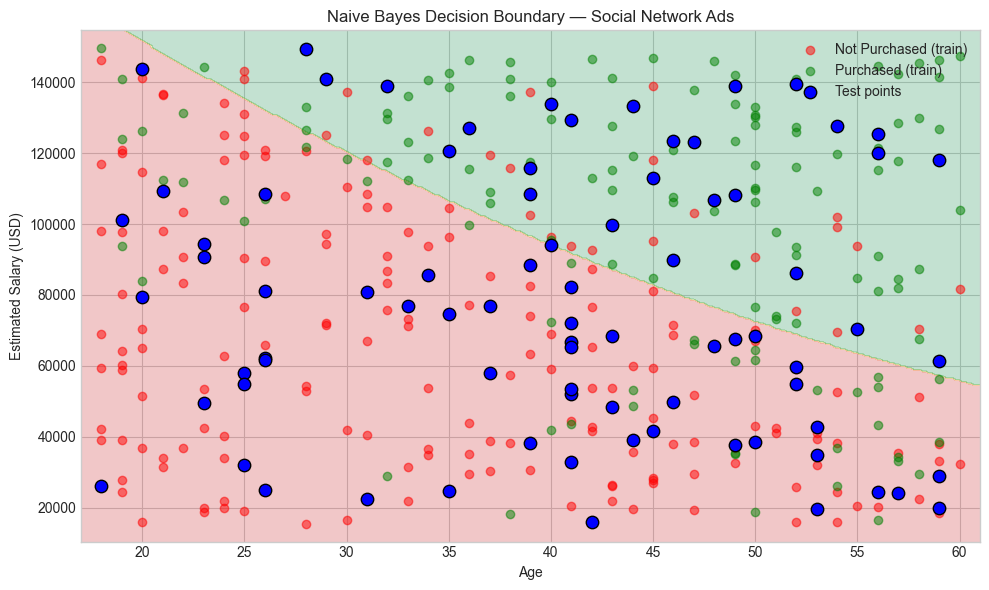

In [63]:
# Step 7) Visualization — scatter + Naive Bayes decision boundary

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 5000, X[:, 1].max() + 5000
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = classifier.predict(grid).reshape(xx.shape)  # Predicted class at each grid point

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')  # Decision regions
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', label='Not Purchased (train)', alpha=0.5)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='green', label='Purchased (train)', alpha=0.5)
plt.scatter(X_test[:, 0], X_test[:, 1], c='blue', edgecolors='k', s=80, label='Test points')
plt.xlabel('Age')
plt.ylabel('Estimated Salary (USD)')
plt.title('Naive Bayes Decision Boundary — Social Network Ads')
plt.legend()
plt.tight_layout()
plt.show()

## Example 1 — Cell 8: Evaluation

Evaluate with Accuracy, Precision, Recall, F1, and Confusion Matrix.

**What this cell does:** Computes classification metrics on the test set.

,Metric,Value,Description
0,Accuracy,0.8125,Fraction of correct predictions
1,Precision,0.8519,"Of predicted Yes, fraction actually Yes"
2,Recall,0.6765,"Of actual Yes, fraction correctly predicted"
3,F1 Score,0.7541,Balance between Precision and Recall



Confusion Matrix (rows=Actual, cols=Predicted):
[[42  4]
 [11 23]]


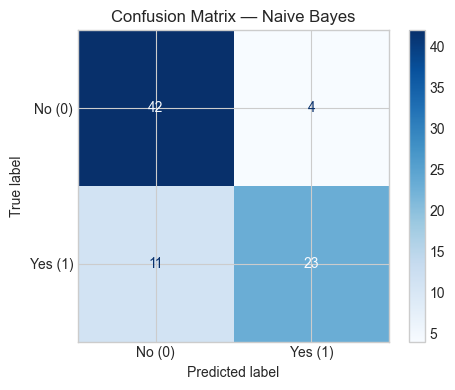


Example 1 Test Accuracy = 0.8125


In [64]:
# Step 8) Evaluation — classification metrics

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Yes, fraction actually Yes',
        'Of actual Yes, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))

cm = confusion_matrix(y_test, y_pred_test)
print('\nConfusion Matrix (rows=Actual, cols=Predicted):')
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — Naive Bayes')
plt.tight_layout()
plt.show()

print(f'\nExample 1 Test Accuracy = {acc:.4f}')

## Why does Naive Bayes work for Social Network Ads?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Probabilistic output** | P(Purchase \| Age, Salary) useful for marketing campaigns |
| 2 | **Fast training** | Only needs mean/variance per class — no iterative optimization |
| 3 | **Gaussian features** | Age and Salary are continuous — GaussianNB fits naturally |
| 4 | **No scaling needed** | Each feature has its own variance per class |
| 5 | **Baseline classifier** | Good starting point before K-NN or Logistic Regression |

> **Summary:** Purchasers tend to be older with higher salary — class-conditional Gaussians capture this pattern.

## Understanding Classification Metrics — Example 1

| Metric | Naive Bayes Context |
|--------|---------------------|
| **Accuracy** | Overall correct posterior decisions |
| **Precision** | When NB predicts Yes, how often correct |
| **Recall** | Of all actual Yes, how many NB finds |
| **F1** | Balance when ~42% purchased |

> Compare with **Logistic Regression** and **K-NN** on the same dataset — similar accuracy, different assumptions.

---
# Example 2: Loan Approval — Naive Bayes

Predict **Approved** vs **Rejected** from four financial features using Gaussian Naive Bayes.

| Column | Role | Description |
|--------|------|-------------|
| `CreditScore` | Feature (X₁) | Credit score (300–850) |
| `Income` | Feature (X₂) | Annual income in USD |
| `LoanAmount` | Feature (X₃) | Requested loan amount in USD |
| `YearsEmployed` | Feature (X₄) | Years at current job |
| `Approved` | Target (y) | 1 = Approved, 0 = Rejected |

**File:** `../Datasets/loan_approval.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the loan approval CSV and inspect the data.

**What this cell does:** Reads `../Datasets/loan_approval.csv` and displays basic statistics.

In [65]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/loan_approval.csv')

FEATURE_COLS = ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']
TARGET_COL = 'Approved'

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nClass balance ({TARGET_COL}):')
print(dataset[TARGET_COL].value_counts())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
0,452.0,87003,152038.0,4.2,0
1,785.0,108211,134862.0,5.1,1
2,698.0,77733,128834.0,6.6,1
3,620.0,90318,103848.0,19.9,1
4,456.0,134953,62921.0,14.2,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CreditScore    249 non-null    float64
 1   Income         250 non-null    int64  
 2   LoanAmount     249 non-null    float64
 3   YearsEmployed  250 non-null    float64
 4   Approved       250 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 9.9 KB

Statistical summary:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
count,249.000000,250.000000,249.000000,250.000000,250.000000
mean,585.995984,82134.284000,91971.630522,10.466800,0.500000
std,133.107085,34366.209563,49499.083375,5.456677,0.501003
min,351.000000,25301.000000,11062.000000,1.000000,0.000000
25%,480.000000,53138.000000,47841.000000,5.825000,0.000000
50%,583.000000,80214.000000,96900.000000,10.750000,0.500000
75%,695.000000,112522.500000,129180.000000,15.150000,1.000000
max,813.000000,137893.000000,178152.000000,19.900000,1.000000



Class balance (Approved):
Approved
0    125
1    125
Name: count, dtype: int64

Shape: 250 rows x 5 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

This dataset includes missing values in features to demonstrate `SimpleImputer`.

**What this cell does:** Checks for nulls, removes duplicates, and imputes missing values.

In [66]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
print(f'\nDuplicates removed: {rows_before - len(dataset)}')

if dataset[TARGET_COL].isnull().sum() > 0:
    dataset = dataset.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    print('Rows with missing target removed')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
cols = FEATURE_COLS + [TARGET_COL]
if dataset[cols].isnull().sum().sum() > 0:
    dataset[cols] = imputer.fit_transform(dataset[cols])
    print('Missing feature values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {len(dataset)}')

Missing values per column:
CreditScore      1
Income           0
LoanAmount       1
YearsEmployed    0
Approved         0
dtype: int64

Duplicates removed: 0
Missing feature values imputed with mean

Rows after cleaning: 250


## Example 2 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [67]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')

No categorical columns — encoding skipped.
Feature columns: ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']


## Example 2 — Cell 4: Splitting the Data

Define X (4 features) and y (Approved), then split 80/20 with stratify.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [68]:
# Step 4) Train-Test split

X = dataset[FEATURE_COLS].values
y = dataset[TARGET_COL].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train class counts: {np.bincount(y_train)}')
print(f'y_test class counts:  {np.bincount(y_test)}')

X_train shape: (200, 4)
X_test shape:  (50, 4)
y_train class counts: [100 100]
y_test class counts:  [25 25]


## Example 2 — Cell 5: Train the Model

Train GaussianNB on four financial features — learns 4 Gaussians per class.

**What this cell does:** Fits the model and shows class-conditional feature means.

In [69]:
# Step 5) Train Gaussian Naive Bayes

classifier = GaussianNB()
classifier.fit(X_train, y_train)

print('Gaussian Naive Bayes trained successfully.')
print(f'Class priors: Rejected={classifier.class_prior_[0]:.3f}, Approved={classifier.class_prior_[1]:.3f}')

print('\nFeature means per class:')
mean_df = pd.DataFrame(classifier.theta_, columns=FEATURE_COLS, index=['Rejected (0)', 'Approved (1)'])
display(mean_df.round(2))  # theta_ = class-conditional means

Gaussian Naive Bayes trained successfully.
Class priors: Rejected=0.500, Approved=0.500

Feature means per class:


,CreditScore,Income,LoanAmount,YearsEmployed
Rejected (0),519.97,82608.94,101660.44,9.98
Approved (1),651.50,84877.07,79413.12,10.91


## Example 2 — Cell 6: Predict

Predict loan approval on the test set with posterior probabilities.

**What this cell does:** Generates predictions and shows sample outputs.

In [70]:
# Step 6) Predict

y_pred_test = classifier.predict(X_test)
y_proba_test = classifier.predict_proba(X_test)[:, 1]

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    actual = 'Approved' if y_test[i] == 1 else 'Rejected'
    pred = 'Approved' if y_pred_test[i] == 1 else 'Rejected'
    print(f'  Actual={actual}, Predicted={pred}, P(Approved|x)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=Approved, Predicted=Rejected, P(Approved|x)=37.67%
  Actual=Rejected, Predicted=Rejected, P(Approved|x)=13.93%
  Actual=Rejected, Predicted=Rejected, P(Approved|x)=14.58%
  Actual=Rejected, Predicted=Rejected, P(Approved|x)=8.55%
  Actual=Rejected, Predicted=Approved, P(Approved|x)=67.21%


## Example 2 — Cell 7: Visualization

Plot **class-conditional means** (heatmap) and **confusion matrix**.

**What this cell does:** Compares average feature values for Approved vs Rejected applicants.

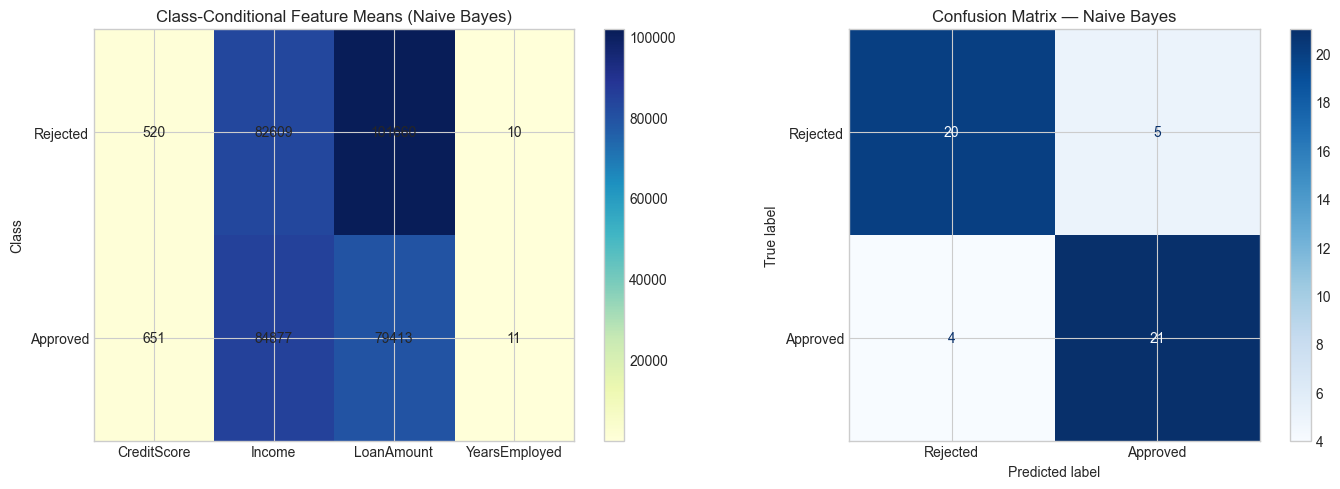

In [71]:
# Step 7) Visualization — feature means heatmap + confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: heatmap of feature means per class ---
mean_df = pd.DataFrame(classifier.theta_, columns=FEATURE_COLS, index=['Rejected', 'Approved'])
im = axes[0].imshow(mean_df.values, cmap='YlGnBu', aspect='auto')
axes[0].set_xticks(range(len(mean_df.columns)))
axes[0].set_xticklabels(mean_df.columns)
axes[0].set_yticks(range(len(mean_df.index)))
axes[0].set_yticklabels(mean_df.index)
for i in range(len(mean_df.index)):
    for j in range(len(mean_df.columns)):
        axes[0].text(j, i, f'{mean_df.values[i, j]:.0f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Class-Conditional Feature Means (Naive Bayes)')
axes[0].set_ylabel('Class')

# --- Right: confusion matrix ---
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix — Naive Bayes')

plt.tight_layout()
plt.show()

## Example 2 — Cell 8: Evaluation

Full classification report with Accuracy, Precision, Recall, and F1.

**What this cell does:** Computes and displays evaluation metrics.

In [72]:
# Step 8) Evaluation

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Approved, fraction actually approved',
        'Of actual Approved, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))

print('\nDetailed classification report:')
print(classification_report(y_test, y_pred_test, target_names=['Rejected (0)', 'Approved (1)']))

print(f'\nExample 2 Test Accuracy = {acc:.4f}')

,Metric,Value,Description
0,Accuracy,0.8200,Fraction of correct predictions
1,Precision,0.8077,"Of predicted Approved, fraction actually approved"
2,Recall,0.8400,"Of actual Approved, fraction correctly predicted"
3,F1 Score,0.8235,Balance between Precision and Recall



Detailed classification report:
              precision    recall  f1-score   support

Rejected (0)       0.83      0.80      0.82        25
Approved (1)       0.81      0.84      0.82        25

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50


Example 2 Test Accuracy = 0.8200


## Why does Naive Bayes work for Loan Approval?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Clear class differences** | Approved applicants have higher credit/income on average |
| 2 | **Independent assumption** | Approximation OK when features provide complementary signals |
| 3 | **Fast & simple** | No hyperparameters to tune — good baseline |
| 4 | **Probabilities** | P(Approved \| x) supports risk-based thresholds |
| 5 | **Balanced classes** | 50/50 split — accuracy is meaningful |

> **Insight:** Heatmap shows Approved class has higher CreditScore and Income means — matches business logic.

## Understanding Classification Metrics — Example 2

| Scenario | Focus Metric |
|----------|--------------|
| **False approval costly** | **Precision** |
| **False rejection costly** | **Recall** |
| **Balanced cost** | **Accuracy** or **F1** |

> **Limitation:** If features are **strongly correlated** (Income vs LoanAmount), the independence assumption is violated — consider Logistic Regression or tree models.